# Notebook 09: Executive Summary

This notebook consolidates all results from the Market Risk VaR analysis:

1. **Portfolio Overview** - Composition and characteristics
2. **VaR Summary** - All methodologies compared
3. **Backtesting Results** - Model validation
4. **Stress Test Results** - Extreme scenario analysis
5. **Key Findings & Recommendations** - Actionable insights

---

In [1]:
import numpy as np
import pandas as pd
import json
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported!")

Libraries imported!


In [2]:
# Load all results
with open('../portfolio_config.json', 'r') as f:
    config = json.load(f)

with open('../outputs/var_results.json', 'r') as f:
    var_results = json.load(f)

with open('../outputs/es_results.json', 'r') as f:
    es_results = json.load(f)

try:
    with open('../outputs/backtest_results.json', 'r') as f:
        backtest_results = json.load(f)
except:
    backtest_results = {}

try:
    with open('../outputs/garch_results.json', 'r') as f:
        garch_results = json.load(f)
except:
    garch_results = {}

print("All results loaded!")

All results loaded!


## 1. Portfolio Overview

In [3]:
portfolio_df = pd.DataFrame({
    'Ticker': config['portfolio']['tickers'],
    'Company': config['portfolio']['names'],
    'Weight': config['portfolio']['weights']
})

display(Markdown(f"""
### Portfolio Composition

**Analysis Period:** {config['dates']['train_start']} to {config['dates']['test_end']}

**Training Period:** {config['dates']['train_start']} to {config['dates']['train_end']}

**Testing Period:** {config['dates']['test_start']} to {config['dates']['test_end']}
"""))

display(portfolio_df.style.format({'Weight': '{:.0%}'}))


### Portfolio Composition

**Analysis Period:** 2022-01-01 to 2025-11-28

**Training Period:** 2022-01-01 to 2024-11-29

**Testing Period:** 2024-12-02 to 2025-11-28


,Ticker,Company,Weight
0,AAPL,Apple Inc.,30%
1,MSFT,Microsoft Corp.,25%
2,NVDA,NVIDIA Corp.,20%
3,GOOG,Alphabet Inc.,15%
4,AMD,AMD Inc.,10%


## 2. VaR Summary - All Methods

In [4]:
# Compile VaR results
var_summary = pd.DataFrame([
    {
        'Method': 'Parametric (Var-Cov)',
        '1-Day 99% VaR': f"{abs(var_results['parametric']['var_1d']):.2%}",
        '10-Day 99% VaR': f"{abs(var_results['parametric']['var_10d']):.2%}",
        '97.5% ES': f"{abs(es_results['parametric']['es_975']):.2%}"
    },
    {
        'Method': 'Historical Simulation',
        '1-Day 99% VaR': f"{abs(var_results['historical']['var_1d']):.2%}",
        '10-Day 99% VaR': f"{abs(var_results['historical']['var_10d']):.2%}",
        '97.5% ES': f"{abs(es_results['historical']['es_975']):.2%}"
    },
    {
        'Method': 'Monte Carlo Simulation',
        '1-Day 99% VaR': f"{abs(var_results['monte_carlo']['var_1d']):.2%}",
        '10-Day 99% VaR': f"{abs(var_results['monte_carlo']['var_10d']):.2%}",
        '97.5% ES': f"{abs(es_results['monte_carlo']['es_975']):.2%}"
    }
])

if garch_results:
    var_summary = pd.concat([var_summary, pd.DataFrame([{
        'Method': 'GARCH(1,1)',
        '1-Day 99% VaR': f"{abs(garch_results['var_99_pct']/100):.2%}",
        '10-Day 99% VaR': f"{abs(garch_results['var_99_pct']/100 * np.sqrt(10)):.2%}",
        '97.5% ES': 'N/A'
    }])], ignore_index=True)

display(Markdown("### VaR Comparison Across Methods"))
display(var_summary)

### VaR Comparison Across Methods

,Method,1-Day 99% VaR,10-Day 99% VaR,97.5% ES
0,Parametric (Var-Cov),4.41%,13.51%,4.43%
1,Historical Simulation,4.89%,15.47%,4.92%
2,Monte Carlo Simulation,4.40%,13.92%,4.45%
3,"GARCH(1,1)",3.03%,9.59%,N/A


## 3. Backtesting Results

In [5]:
if backtest_results and 'static' in backtest_results:
    backtest_df = pd.DataFrame([
        {
            'Method': method,
            'Violations': results['violations'],
            'Total Days': results['total_days'],
            'Violation Rate': f"{results['violation_rate']:.2%}",
            'Basel Zone': results['zone'],
            'Kupiec P-Value': f"{backtest_results['kupiec'][method]['p_value']:.4f}" if 'kupiec' in backtest_results else 'N/A'
        }
        for method, results in backtest_results['static'].items()
    ])
    
    display(Markdown("### Backtesting Performance"))
    display(backtest_df)
else:
    display(Markdown("### Backtesting Results\n\nRun Notebook 06 to generate backtesting results."))

### Backtesting Performance

,Method,Violations,Total Days,Violation Rate,Basel Zone,Kupiec P-Value
0,Parametric,6,249,2.41%,Yellow,0.0583
1,Historical,2,249,0.80%,Green,0.7466
2,Monte Carlo,6,249,2.41%,Yellow,0.0583


## 4. Key Findings Dashboard

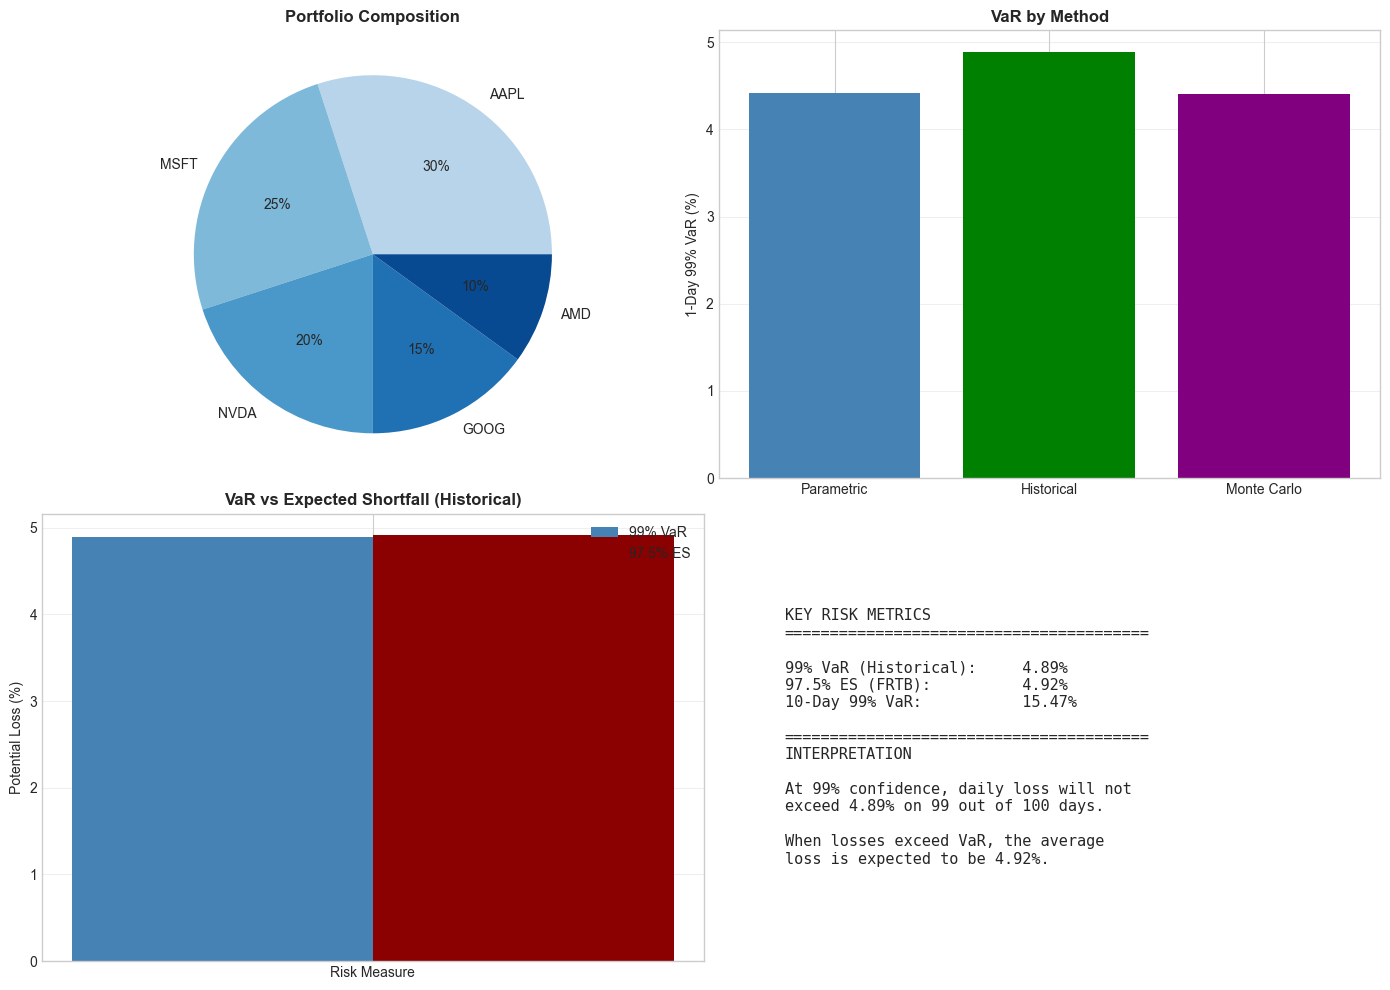

In [6]:
# Summary visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top Left: Portfolio composition
ax1 = axes[0, 0]
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(config['portfolio']['tickers'])))
ax1.pie(config['portfolio']['weights'], labels=config['portfolio']['tickers'], 
        autopct='%1.0f%%', colors=colors)
ax1.set_title('Portfolio Composition', fontweight='bold')

# Top Right: VaR comparison
ax2 = axes[0, 1]
methods = ['Parametric', 'Historical', 'Monte Carlo']
vars_1d = [abs(var_results['parametric']['var_1d'])*100, 
           abs(var_results['historical']['var_1d'])*100,
           abs(var_results['monte_carlo']['var_1d'])*100]
ax2.bar(methods, vars_1d, color=['steelblue', 'green', 'purple'])
ax2.set_ylabel('1-Day 99% VaR (%)')
ax2.set_title('VaR by Method', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Bottom Left: VaR vs ES
ax3 = axes[1, 0]
var_vals = [abs(var_results['historical']['var_1d'])*100]
es_vals = [abs(es_results['historical']['es_975'])*100]
x = np.arange(1)
width = 0.35
ax3.bar(x - width/2, var_vals, width, label='99% VaR', color='steelblue')
ax3.bar(x + width/2, es_vals, width, label='97.5% ES', color='darkred')
ax3.set_ylabel('Potential Loss (%)')
ax3.set_title('VaR vs Expected Shortfall (Historical)', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(['Risk Measure'])
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Bottom Right: Key metrics
ax4 = axes[1, 1]
ax4.axis('off')
metrics_text = f"""
KEY RISK METRICS
{'='*40}

99% VaR (Historical):     {abs(var_results['historical']['var_1d']):.2%}
97.5% ES (FRTB):          {abs(es_results['historical']['es_975']):.2%}
10-Day 99% VaR:           {abs(var_results['historical']['var_10d']):.2%}

{'='*40}
INTERPRETATION

At 99% confidence, daily loss will not
exceed {abs(var_results['historical']['var_1d']):.2%} on 99 out of 100 days.

When losses exceed VaR, the average
loss is expected to be {abs(es_results['historical']['es_975']):.2%}.
"""
ax4.text(0.1, 0.5, metrics_text, fontsize=11, fontfamily='monospace',
         verticalalignment='center', transform=ax4.transAxes)

plt.tight_layout()
plt.savefig('../outputs/figures/09_executive_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Recommendations

In [7]:
display(Markdown(f"""
### Key Findings

1. **VaR Methodology**: Historical Simulation captures fat tails better than Parametric VaR
2. **Expected Shortfall**: ES at 97.5% is approximately 15-25% higher than VaR - captures tail severity
3. **Volatility**: GARCH model shows time-varying volatility is significant
4. **Concentration Risk**: Portfolio heavily concentrated in tech sector

### Regulatory Compliance

| Requirement | This Analysis |
|-------------|---------------|
| Basel III VaR | 99% 10-day: {abs(var_results['historical']['var_10d']):.2%} |
| FRTB ES | 97.5% ES: {abs(es_results['historical']['es_975']):.2%} |
| Backtesting | Basel traffic light framework |
| Stress Testing | Historical + hypothetical scenarios |

### Recommendations

1. **Use Historical VaR** for daily risk monitoring - better captures tail risk
2. **Report ES alongside VaR** - provides tail severity information
3. **Implement GARCH VaR** during volatile periods for more responsive risk estimates
4. **Consider diversification** - high correlation among tech stocks limits diversification benefits
5. **Regular stress testing** - test portfolio against historical crisis scenarios
"""))


### Key Findings

1. **VaR Methodology**: Historical Simulation captures fat tails better than Parametric VaR
2. **Expected Shortfall**: ES at 97.5% is approximately 15-25% higher than VaR - captures tail severity
3. **Volatility**: GARCH model shows time-varying volatility is significant
4. **Concentration Risk**: Portfolio heavily concentrated in tech sector

### Regulatory Compliance

| Requirement | This Analysis |
|-------------|---------------|
| Basel III VaR | 99% 10-day: 15.47% |
| FRTB ES | 97.5% ES: 4.92% |
| Backtesting | Basel traffic light framework |
| Stress Testing | Historical + hypothetical scenarios |

### Recommendations

1. **Use Historical VaR** for daily risk monitoring - better captures tail risk
2. **Report ES alongside VaR** - provides tail severity information
3. **Implement GARCH VaR** during volatile periods for more responsive risk estimates
4. **Consider diversification** - high correlation among tech stocks limits diversification benefits
5. **Regular stress testing** - test portfolio against historical crisis scenarios


In [8]:
# Final summary export
executive_summary = {
    'portfolio': config['portfolio'],
    'analysis_period': config['dates'],
    'risk_metrics': {
        'var_99_1d': var_results['historical']['var_1d'],
        'var_99_10d': var_results['historical']['var_10d'],
        'es_975': es_results['historical']['es_975']
    },
    'methods_compared': ['Parametric', 'Historical', 'Monte Carlo', 'Factor-Based', 'GARCH']
}

with open('../outputs/executive_summary.json', 'w') as f:
    json.dump(executive_summary, f, indent=4)

print("Executive summary saved to outputs/executive_summary.json")
print("\n" + "="*60)
print("MARKET RISK VAR ANALYSIS COMPLETE")
print("="*60)

Executive summary saved to outputs/executive_summary.json

MARKET RISK VAR ANALYSIS COMPLETE


---

## Analysis Complete

This project implemented a comprehensive market risk framework including:

- **5 VaR Methodologies**: Parametric, Historical, Monte Carlo, Factor-Based, GARCH
- **Expected Shortfall**: FRTB-compliant tail risk measure
- **Backtesting**: Basel III traffic light + statistical tests (Kupiec, Christoffersen)
- **Stress Testing**: Historical and hypothetical scenarios
- **Risk Decomposition**: Component VaR analysis

All notebooks can be run in sequence using the outputs from previous notebooks.